# Complete Exploratory Data Analysis (EDA) Notebook (Template)

**What you get in this notebook**
- Theory in **Markdown** (easy to read + teach)
- Code in **Python cells** (ready to run)
- Clear explanations for each concept
- Works even if you don’t have an external dataset (uses a built-in dataset)
- Also supports your own CSV/Excel file

> Tip: Run cells top-to-bottom. When you use your own dataset, change the file path in the “Load Your Dataset” section.




## 0) EDA: What it is and why it matters (Theory)

**EDA (Exploratory Data Analysis)** is the structured process of understanding a dataset *before* modeling.

### Core outcomes of EDA
1. **Understand structure**: rows, columns, data types
2. **Data quality checks**: missing values, duplicates, inconsistent formats
3. **Distributions**: how each variable behaves (shape, range, skew)
4. **Relationships**: how variables relate (correlation, associations, patterns)
5. **Outliers & anomalies**: points that may be errors or rare events
6. **Insights for next steps**: what preprocessing or feature engineering is needed

### EDA is not “just plots”
Good EDA combines:
- **Statistics** (summary measures, dispersion)
- **Visualization** (human pattern detection)
- **Domain reasoning** (what makes sense in real life)


In [2]:
# 1) Setup: imports & display options

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: better plot resolution
plt.rcParams["figure.dpi"] = 130

# Pandas display options (feel free to adjust)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

print("Ready ✅")


Ready ✅


## 2) Load a dataset

You have two options:
1. **Use a built-in dataset** (so the notebook runs immediately)
2. **Load your own dataset** (CSV/Excel)

Below we load the **Iris dataset** (built-in via scikit-learn), then show how to replace it with your dataset.

If `sklearn` is not available in your environment, you can skip the built-in dataset cell and use the “Load Your Dataset” cell.


In [3]:
# 2A) Load a built-in dataset (Iris)

try:
    from sklearn.datasets import load_iris
    iris = load_iris(as_frame=True)
    df = iris.frame.copy()
    df.rename(columns={"target": "species_id"}, inplace=True)
    df["species"] = df["species_id"].map(dict(enumerate(iris.target_names)))
    print("Built-in dataset loaded: Iris ✅")
    display(df.head())
except Exception as e:
    print("Could not load Iris dataset. Error:", e)
    print("You can still use this notebook by loading your own dataset in section 2B.")


Built-in dataset loaded: Iris ✅


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 2B) Load your dataset (CSV/Excel)

**Theory**
- `pd.read_csv(...)` loads CSV files
- `pd.read_excel(...)` loads Excel files
- Always inspect the first few rows to confirm the dataset loaded correctly.

**Action**
- Uncomment one of the loaders below and update the file path.


In [4]:
# 2B) Load your own dataset (uncomment and set path)

# # CSV example:
# df = pd.read_csv("your_dataset.csv")

# # Excel example:
# df = pd.read_excel("your_dataset.xlsx", sheet_name=0)

# # After loading, always preview:
# display(df.head())


## 3) First look: shape, columns, and samples (Theory)

Before any deep analysis, answer:
- How big is the data? (rows × columns)
- What are the columns?
- What does a typical row look like?
- Are there obvious issues (weird symbols, mixed formats)?


In [5]:
# 3) First look

print("Shape (rows, cols):", df.shape)
print("\nColumns:")
display(pd.Series(df.columns))




Shape (rows, cols): (150, 6)

Columns:


0    sepal length (cm)
1     sepal width (cm)
2    petal length (cm)
3     petal width (cm)
4           species_id
5              species
dtype: object

In [6]:
print("\nRandom sample:")
display(df.sample(min(10, len(df)), random_state=42))


Random sample:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
73,6.1,2.8,4.7,1.2,1,versicolor
18,5.7,3.8,1.7,0.3,0,setosa
118,7.7,2.6,6.9,2.3,2,virginica
78,6.0,2.9,4.5,1.5,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor
31,5.4,3.4,1.5,0.4,0,setosa
64,5.6,2.9,3.6,1.3,1,versicolor
141,6.9,3.1,5.1,2.3,2,virginica
68,6.2,2.2,4.5,1.5,1,versicolor
82,5.8,2.7,3.9,1.2,1,versicolor


In [7]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


## 4) Data types and memory (Theory)

### Why data types matter
- Numeric vs categorical changes the statistics you compute and the plots you use.
- Many EDA mistakes happen due to **wrong types** (e.g., numbers stored as strings).

### What to check
- `df.info()` for types and missing values
- `nunique()` to understand cardinality (how many distinct values)


In [8]:
# 4) Data types and missing counts overview

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_id         150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [9]:
# Cardinality: number of unique values per column (useful for categoricals)

cardinality = df.nunique(dropna=False).sort_values(ascending=False)
display(cardinality)


petal length (cm)    43
sepal length (cm)    35
sepal width (cm)     23
petal width (cm)     22
species_id            3
species               3
dtype: int64

## 5) Missing values (Theory)

### Why missing values matter
Missingness can:
- Reduce usable training data
- Bias results if missingness is not random
- Break algorithms that don’t support NaNs

### Steps
1. Count missing values per column
2. Check missingness percentage
3. Decide what to do:
   - Drop rows/columns (carefully)
   - Impute (mean/median/mode/model-based)
   - Keep NaNs if algorithm can handle them


In [10]:
# 5) Missing values summary

missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

display(missing_table.head(30))


,missing_count,missing_pct
sepal length (cm),0,0.0
sepal width (cm),0,0.0
petal length (cm),0,0.0
petal width (cm),0,0.0
species_id,0,0.0
species,0,0.0


## 6) Duplicate rows (Theory)

Duplicates can occur due to:
- Data collection repetition
- Joining/merging mistakes
- Logging issues

Typical action:
- Confirm duplicates are truly duplicates (not valid repeated events)
- Remove duplicates if appropriate


In [11]:
# 6) Duplicate rows

dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

if dup_count > 0:
    display(df[df.duplicated()].head())


Duplicate rows: 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
142,5.8,2.7,5.1,1.9,2,virginica


## 7) Basic descriptive statistics (Theory)

### For numeric columns
- Central tendency: mean, median
- Spread: std, IQR
- Range: min/max
- Shape: skewness

### For categorical columns
- Frequency counts
- Most common category


In [12]:
# 7A) Separate numeric and categorical columns

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species_id']
Categorical columns: ['species']


In [13]:
# 7B) Summary statistics for numeric columns

if numeric_cols:
    display(df[numeric_cols].describe().T)
else:
    print("No numeric columns found.")


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
species_id,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [14]:
# 7C) Summary for categorical columns

for c in categorical_cols[:20]:  # limit to first 20 to avoid overload
    print(f"\nColumn: {c}")
    display(df[c].value_counts(dropna=False).head(20))



Column: species


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 8) Univariate analysis: distributions (Theory)

Univariate analysis = study one variable at a time.

### Numeric distributions
- Histogram: shows frequency distribution
- Boxplot: shows median, IQR, potential outliers

### Categorical distributions
- Bar chart: category counts


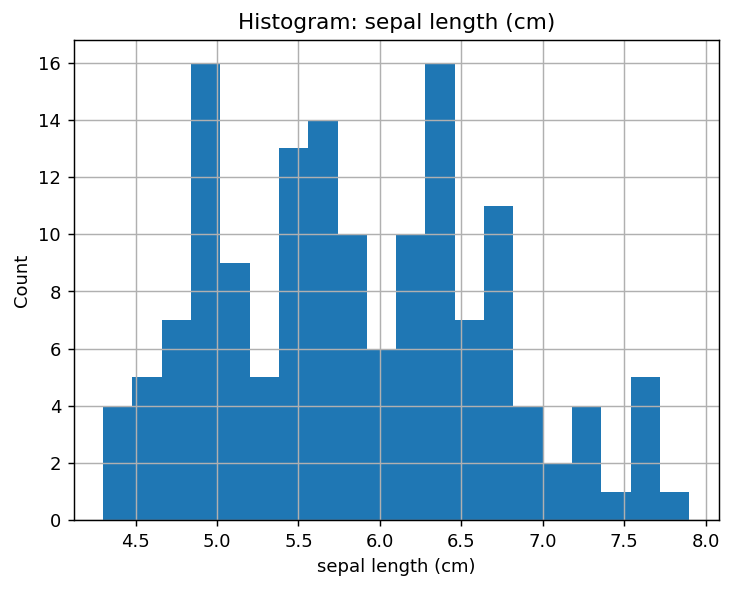

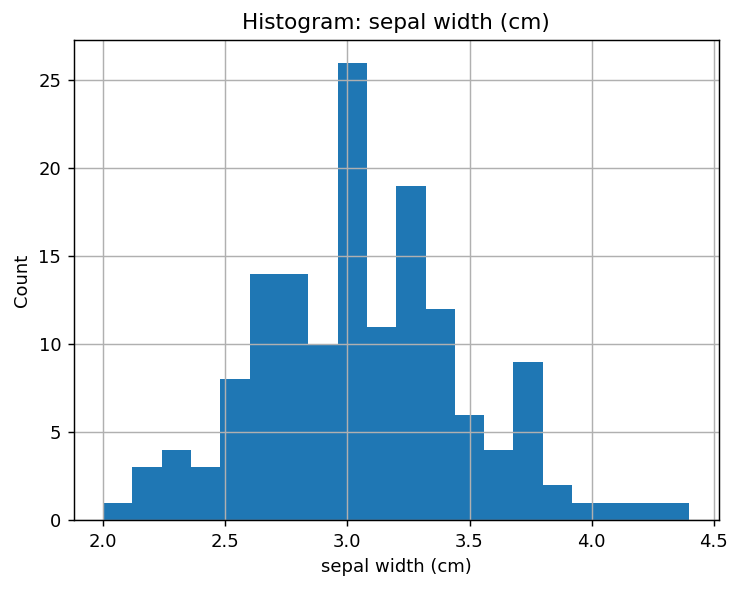

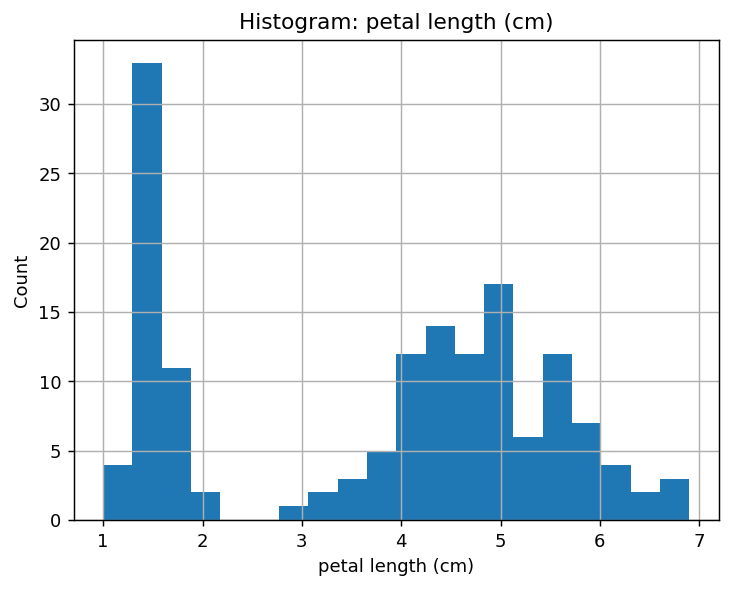

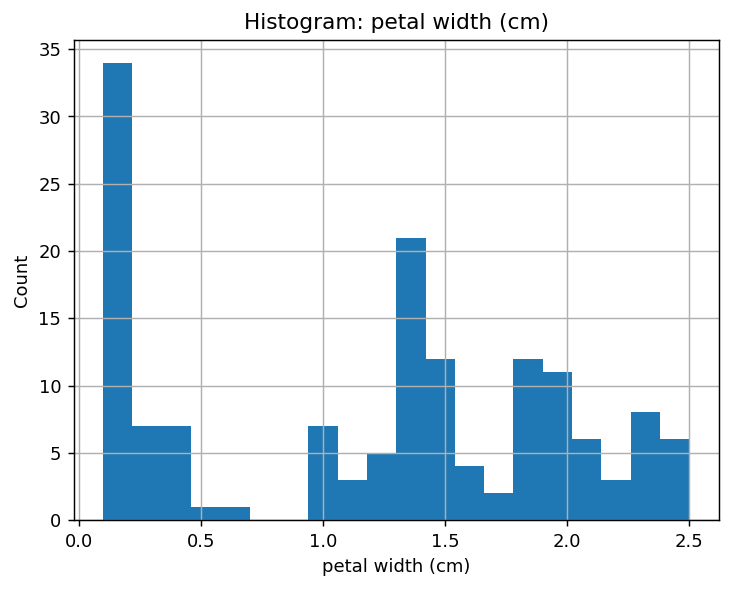

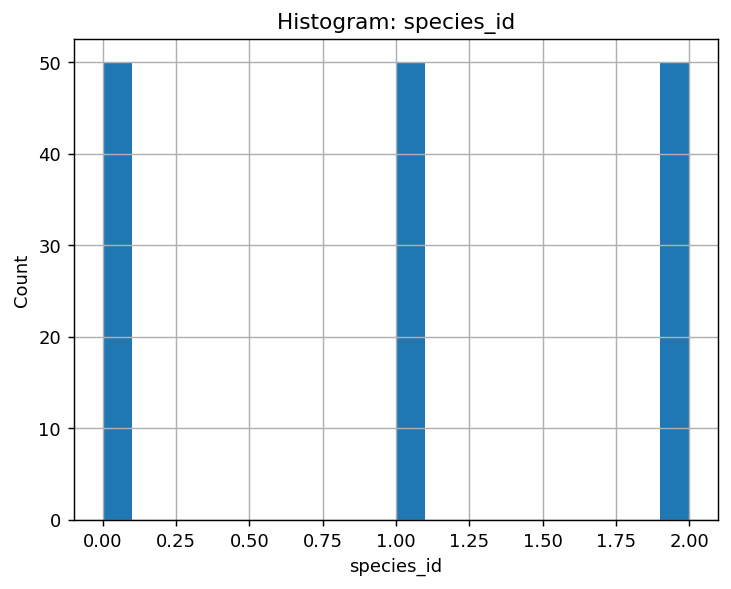

In [15]:
# 8A) Histograms for numeric columns

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=20)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


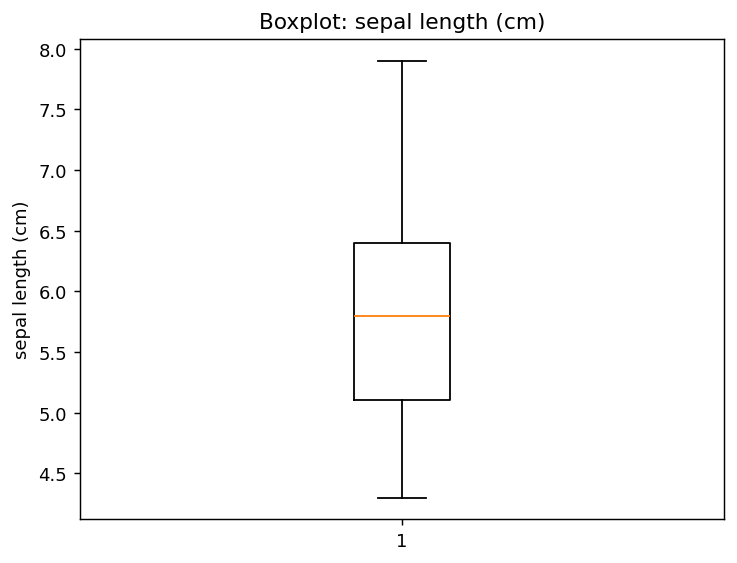

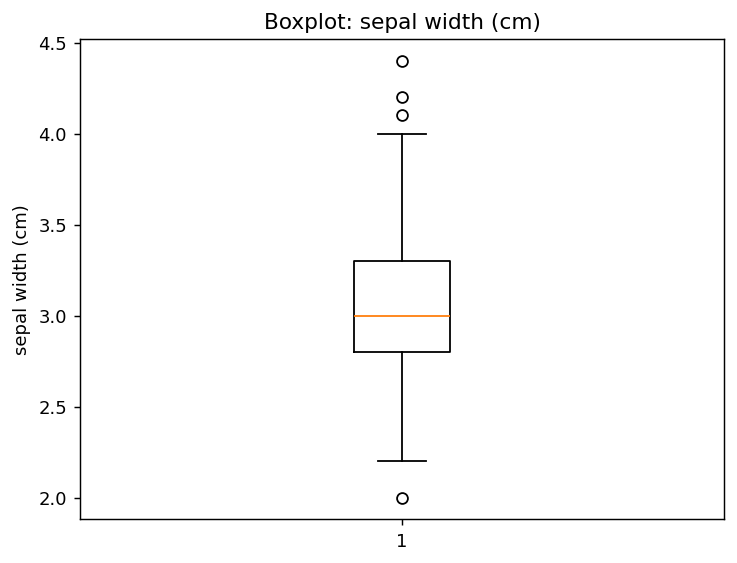

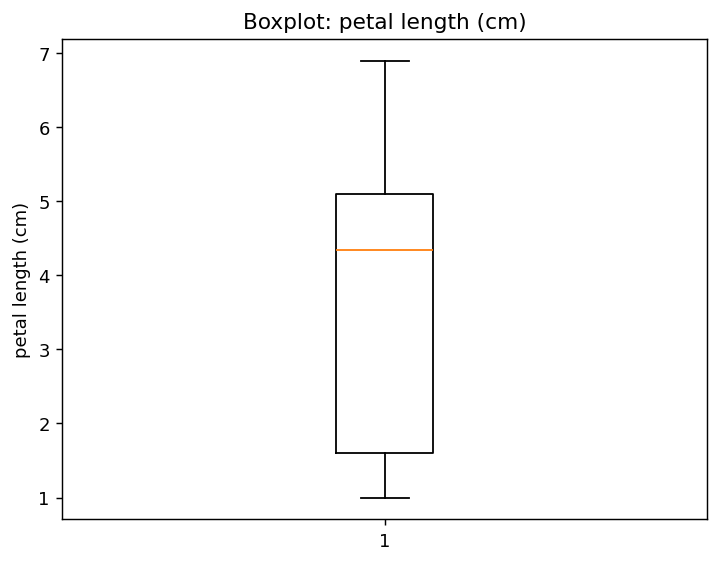

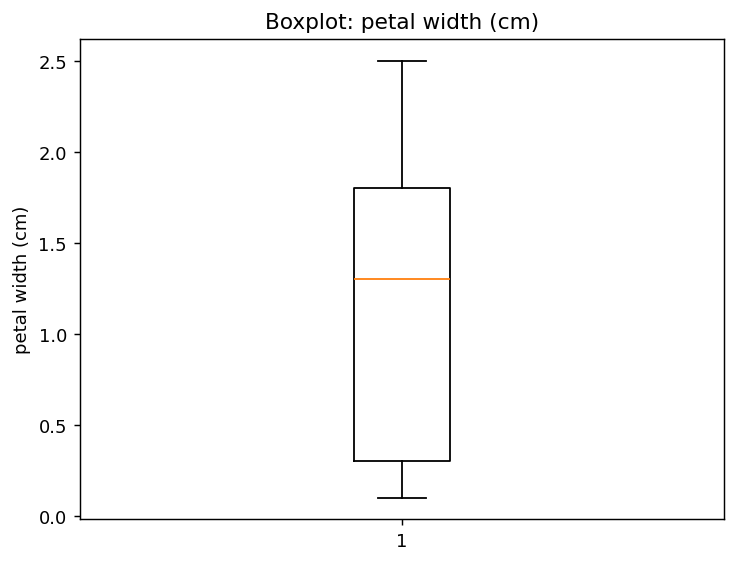

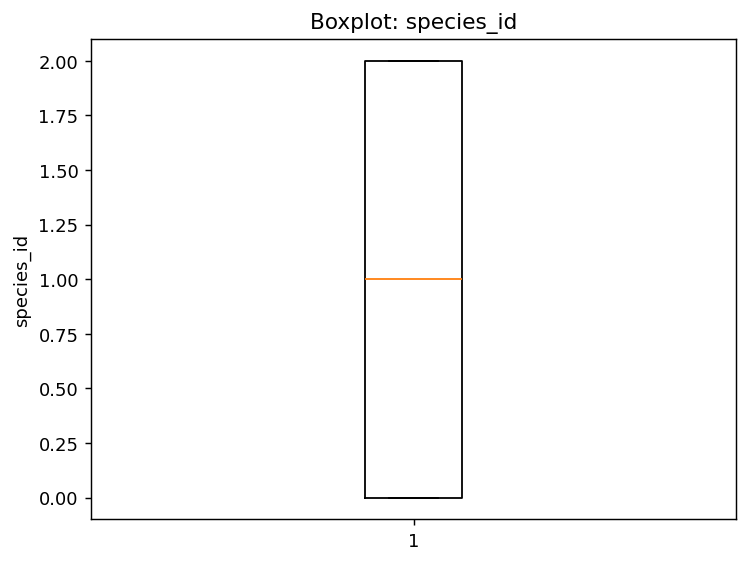

In [16]:
# 8B) Boxplots for numeric columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.show()


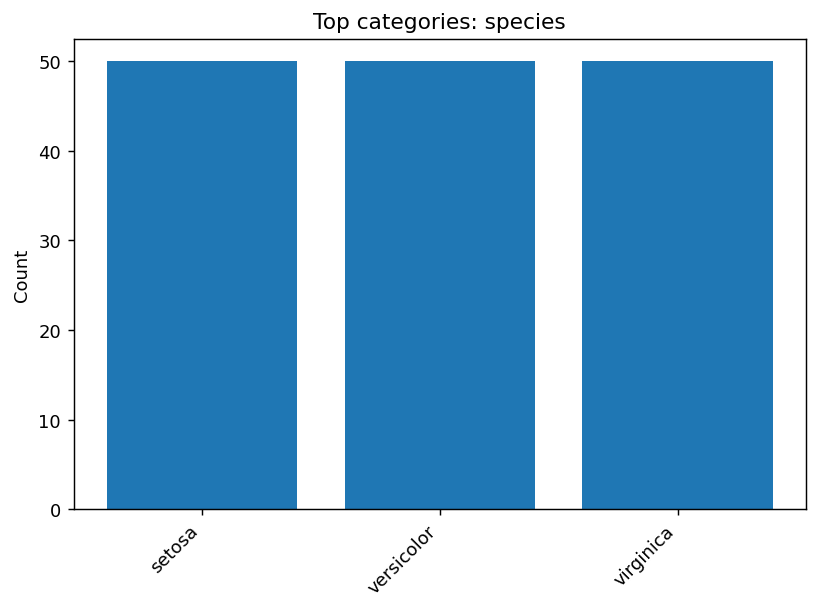

In [17]:
# 8C) Bar charts for categorical columns (top categories)

for col in categorical_cols[:10]:
    plt.figure()
    vc = df[col].value_counts(dropna=False).head(20)
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"Top categories: {col}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 9) Bivariate analysis: relationships (Theory)

Bivariate analysis = study relationship between two variables.

### Typical pairs and plots
- Numeric vs Numeric: scatter plot, correlation
- Numeric vs Categorical: boxplots grouped by category
- Categorical vs Categorical: contingency table (crosstab)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
species_id,0.782561,-0.426658,0.949035,0.956547,1.000000


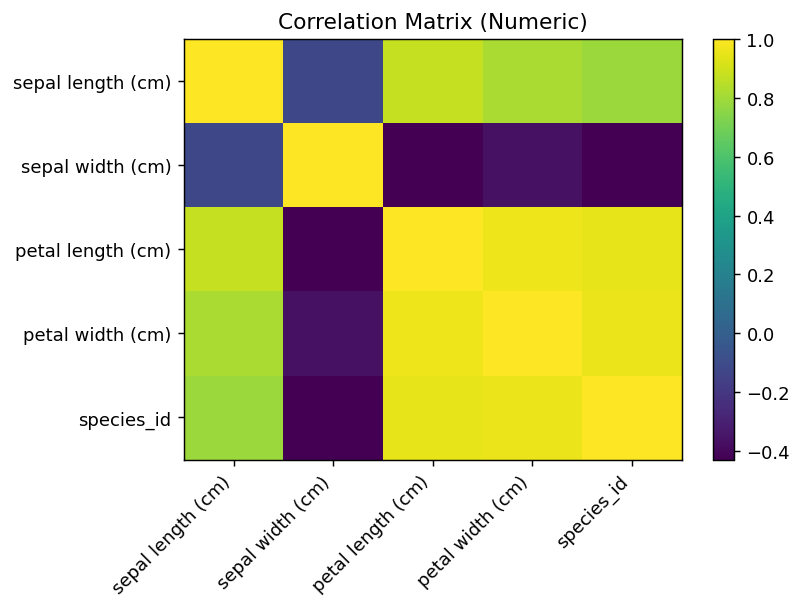

In [18]:
# 9A) Correlation matrix (numeric only)

if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    display(corr)

    plt.figure()
    plt.imshow(corr, aspect="auto")
    plt.title("Correlation Matrix (Numeric)")
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
    plt.yticks(range(len(numeric_cols)), numeric_cols)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 numeric columns for correlation analysis.")


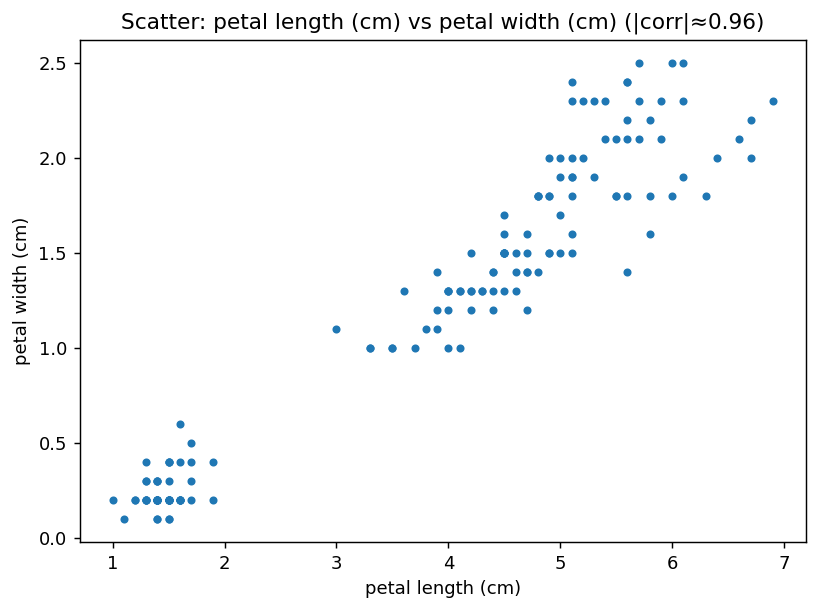

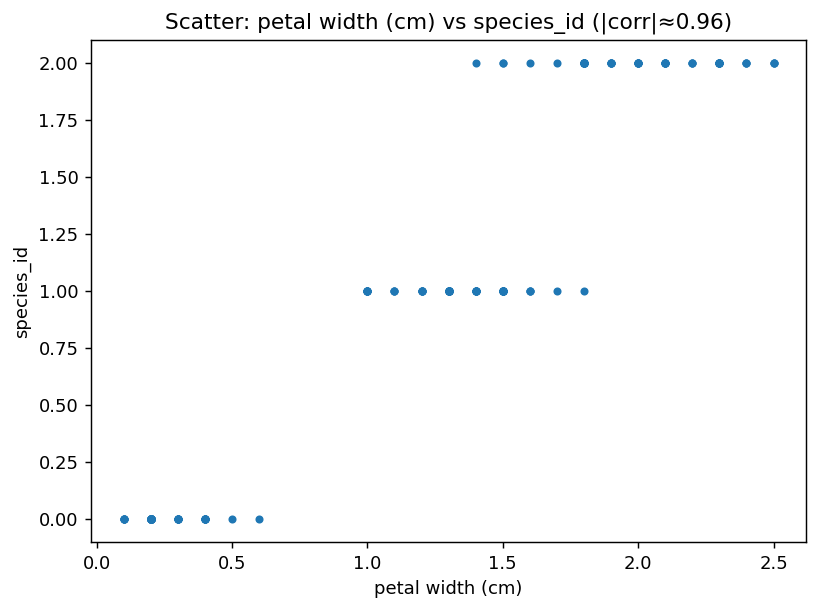

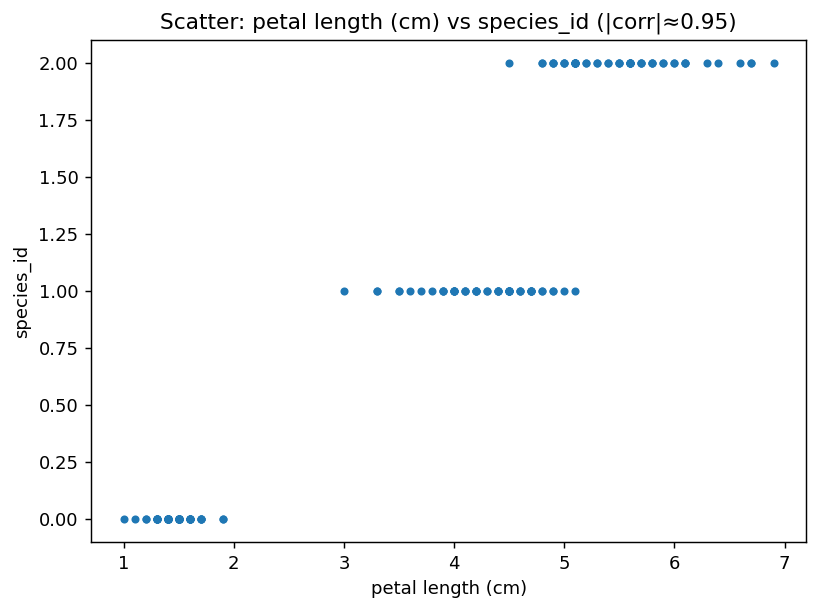

In [19]:
# 9B) Scatter plots for a few numeric pairs (auto-select top 3 pairs by absolute correlation)

if len(numeric_cols) >= 2:
    corr_abs = df[numeric_cols].corr(numeric_only=True).abs()
    # Extract upper triangle pairs
    pairs = []
    cols = numeric_cols
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            pairs.append((cols[i], cols[j], corr_abs.iloc[i, j]))
    pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)[:3]

    for x, y, c in pairs_sorted:
        plt.figure()
        plt.scatter(df[x], df[y], s=12)
        plt.title(f"Scatter: {x} vs {y} (|corr|≈{c:.2f})")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()
else:
    print("Need at least 2 numeric columns for scatter plots.")


C:\Users\HP\AppData\Local\Temp\ipykernel_14800\2311314973.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, vert=True)


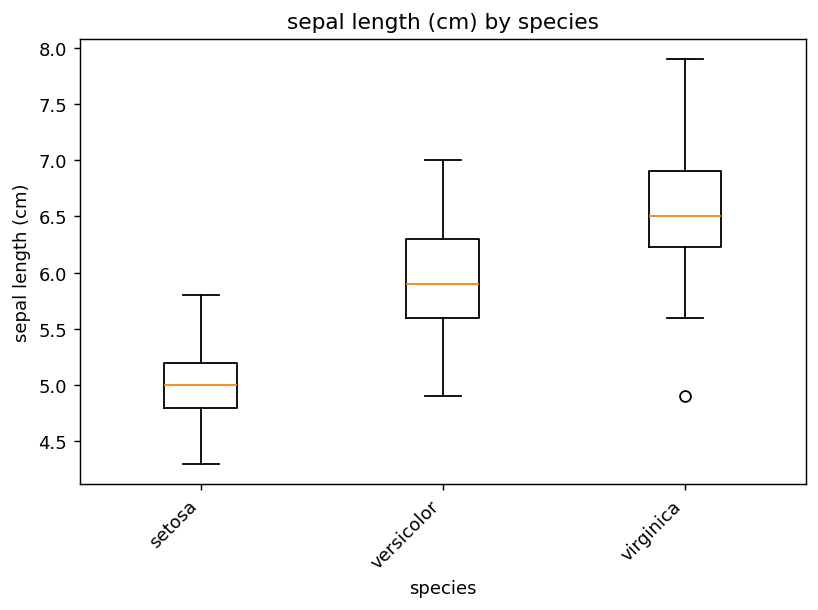

In [20]:
# 9C) Numeric vs Categorical (grouped boxplot)
# Example: choose first numeric and first categorical if available

if numeric_cols and categorical_cols:
    num = numeric_cols[0]
    cat = categorical_cols[0]

    groups = []
    labels = []
    for k, g in df[[cat, num]].dropna().groupby(cat):
        groups.append(g[num].values)
        labels.append(str(k))

    plt.figure()
    plt.boxplot(groups, labels=labels, vert=True)
    plt.title(f"{num} by {cat}")
    plt.xlabel(cat)
    plt.ylabel(num)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 1 numeric and 1 categorical column for grouped boxplots.")


In [21]:
# 9D) Categorical vs Categorical using crosstab (contingency table)

if len(categorical_cols) >= 2:
    c1, c2 = categorical_cols[0], categorical_cols[1]
    ct = pd.crosstab(df[c1], df[c2], dropna=False)
    display(ct)

    plt.figure()
    plt.imshow(ct.values, aspect="auto")
    plt.title(f"Crosstab Heatmap: {c1} vs {c2}")
    plt.xticks(range(ct.shape[1]), ct.columns.astype(str), rotation=45, ha="right")
    plt.yticks(range(ct.shape[0]), ct.index.astype(str))
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 categorical columns for crosstab analysis.")


Need at least 2 categorical columns for crosstab analysis.


## 10) Outlier detection (Theory)

Outliers are values far from the typical range.
They can be:
- **Errors** (wrong units, typos)
- **Rare but real** events (fraud, extreme weather)
- **Distribution tails** (not necessarily “bad”)

### Two common methods
1. **IQR rule**
   - Outliers are outside: `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`
2. **Z-score**
   - Standardizes values: `(x - mean) / std`
   - Often flag |z| > 3 (rule of thumb)


In [22]:
# 10A) IQR-based outlier detection for numeric columns

def iqr_outliers(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return mask, low, high

outlier_summary = []
for col in numeric_cols:
    mask, low, high = iqr_outliers(df[col])
    outlier_summary.append({
        "column": col,
        "iqr_low": low,
        "iqr_high": high,
        "outlier_count": int(mask.sum()),
        "outlier_pct": float((mask.sum() / len(df) * 100) if len(df) else 0)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)
display(outlier_df)


,column,iqr_low,iqr_high,outlier_count,outlier_pct
1,sepal width (cm),2.05,4.05,4,2.666667
0,sepal length (cm),3.15,8.35,0,0.000000
2,petal length (cm),-3.65,10.35,0,0.000000
3,petal width (cm),-1.95,4.05,0,0.000000
4,species_id,-3.00,5.00,0,0.000000


In [23]:
# 10B) Z-score outlier detection (|z| > 3) for numeric columns

z_summary = []
for col in numeric_cols:
    s = df[col].astype(float)
    mean = s.mean()
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        z_count = 0
    else:
        z = (s - mean) / std
        z_count = int((z.abs() > 3).sum())
    z_summary.append({"column": col, "z_outliers(|z|>3)": z_count})

display(pd.DataFrame(z_summary).sort_values("z_outliers(|z|>3)", ascending=False))


,column,z_outliers(|z|>3)
1,sepal width (cm),1
0,sepal length (cm),0
2,petal length (cm),0
3,petal width (cm),0
4,species_id,0


## 11) Data quality: inconsistent formats (Theory)

Common issues:
- Numbers stored as strings (e.g., `"1,234"`)
- Dates stored as text
- Mixed units (cm vs m, LKR vs USD)
- Extra whitespace (`" Male"` vs `"Male"`)

### Typical actions
- Strip whitespace in text columns
- Standardize categories (lowercase, mapping)
- Parse dates using `pd.to_datetime()`


In [24]:
# 11A) Trim whitespace in object (string) columns

for col in categorical_cols:
    # Only apply if it's likely string-like
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

print("Whitespace trimming done (for string-like categoricals).")


Whitespace trimming done (for string-like categoricals).


In [25]:
# 11B) Attempt date parsing for columns that look like dates (optional heuristic)

possible_date_cols = []
for col in df.columns:
    if "date" in col.lower() or "time" in col.lower():
        possible_date_cols.append(col)

print("Possible date/time columns:", possible_date_cols)

# Example conversion (uncomment if needed):
# df["your_date_col"] = pd.to_datetime(df["your_date_col"], errors="coerce")


Possible date/time columns: []


## 12) Group-based insights (Theory)

When you have categorical groupings (e.g., `department`, `gender`, `species`):
- Compare averages by group
- Compare distributions by group
- Identify group-specific anomalies


In [26]:
# 12) Grouped statistics: mean/median of numeric columns by a categorical column

if categorical_cols and numeric_cols:
    group_col = categorical_cols[0]
    grouped = df.groupby(group_col)[numeric_cols].agg(["count", "mean", "median", "std"])
    display(grouped)
else:
    print("Need at least 1 categorical and 1 numeric column for group-based insights.")


sepal length (cm)                         sepal width (cm)                         petal length (cm)  \
                       count   mean median       std            count   mean median       std             count   
species                                                                                                           
setosa                    50  5.006    5.0  0.352490               50  3.428    3.4  0.379064                50   
versicolor                50  5.936    5.9  0.516171               50  2.770    2.8  0.313798                50   
virginica                 50  6.588    6.5  0.635880               50  2.974    3.0  0.322497                50   

                                   petal width (cm)                         species_id                   
             mean median       std            count   mean median       std      count mean median  std  
species                                                                                                  
setosa      1.462   1.50  0.173664               50  0.246    0.2  0.105386         50  0.0    0.0  0.0  
versicolor  4.260   4.35  0.469911               50  1.326    1.3  0.197753         50  1.0    1.0  0.0  
virginica   5.552   5.55  0.551895               50  2.026    2.0  0.274650         50  2.0    2.0  0.0

## 13) A simple EDA report summary (Theory)

At the end of EDA, you should be able to write:

1. Dataset size and columns
2. Data types (numeric/categorical/date/text)
3. Missing values (where, how much, likely reasons)
4. Duplicates and consistency checks
5. Key distributions (skewed? bounded?)
6. Strong relationships (correlations, associations)
7. Outliers (where they occur, likely causes)
8. Recommended preprocessing steps
9. Potential feature engineering ideas


In [27]:
# 13) Auto-generated quick EDA summary (lightweight)

summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "numeric_cols": len(numeric_cols),
    "categorical_cols": len(categorical_cols),
    "total_missing_cells": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum())
}

display(pd.DataFrame([summary]))


,rows,columns,numeric_cols,categorical_cols,total_missing_cells,duplicate_rows
0,150,6,5,1,0,1


## 14) Next steps: EDA → preprocessing → modeling (Theory)

Typical pipeline:
1. **EDA** (this notebook)
2. **Preprocessing**
   - Missing value handling
   - Encoding categoricals
   - Scaling/normalization
   - Train/test split (avoid leakage)
3. **Feature engineering**
   - Ratios, log transforms, bins
   - Domain features
4. **Modeling**
5. **Evaluation & iteration**

> EDA should inform *exactly what preprocessing you do*.


## Appendix A: EDA checklist (quick)

- [ ] `shape`, `head`, `sample`
- [ ] `info()` + type checks
- [ ] missing table + plan
- [ ] duplicates check
- [ ] numeric `describe()`
- [ ] categorical value counts
- [ ] histograms + boxplots
- [ ] correlations + scatter
- [ ] grouped comparisons
- [ ] outlier flags (IQR/Z)
- [ ] data consistency (strings, dates)
- [ ] short written summary + next actions
